# 02. EdgeMTSC -- отдельные temporal matrices для пар каналов

### Идея эксперимента

В обычном IMP одна обучаемая матрица `C x C`: связь `j -> i` задается одним весом и одинаково действует на всем временном ряду.

Хочу проверить более сильную гипотезу -- для каждой пары latent channels `(i, j)` учить свою временную матрицу. Полная произвольная `128 x 128` матрица на каждую пару слишком быстро раздует модель, поэтому беру структурированный вариант -- **Toeplitz matrix** с окном 5. На практике это ровно отдельный обучаемый `Conv1d`-kernel для каждой пары каналов.

То есть вместо одного веса `W[i, j]` у пары теперь пять весов для лагов `[-2, -1, 0, +1, +2]`. Такой блок уже умеет передавать сообщение между каналами с небольшим временным сдвигом. Окно ограничиваю пятью лагами, чтобы отдельные pairwise relations не раздули модель на порядок.

Обучаю локально и хочу сравнивать модели в одном parameter budget, поэтому для pairwise-варианта беру ширину `176 -> 44`. В итоге получается около `181k` параметров, почти столько же, сколько у standard EdgeMTSC и Transformer. Остальная архитектура -- те же `SKB`, `LKB`, `sAC` из предыдущего ноутбука.


In [1]:
from pathlib import Path
from copy import deepcopy
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
(ROOT / "figures").mkdir(exist_ok=True)
(ROOT / "results").mkdir(exist_ok=True)

data = np.load(ROOT / "data/uci_har_raw.npz")
X_train = data["X_train"]
y_train = data["y_train"]
subjects_train = data["subjects_train"]
X_test = data["X_test"]
y_test = data["y_test"]

CLASS_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING",
]

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 35
PATIENCE = 7
LR = 8e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.05

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: mps


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def standardize(X_fit, X_other):
    mean = X_fit.mean(axis=(0, 2), keepdims=True)
    std = X_fit.std(axis=(0, 2), keepdims=True) + 1e-6
    return (X_fit - mean) / std, (X_other - mean) / std, mean, std


def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss_sum += criterion(logits, y).item() * len(y)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())

    return {
        "loss": loss_sum / len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
    }


def fit(model, train_loader, val_loader=None, epochs=MAX_EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_f1": []}
    best_state = deepcopy(model.state_dict())
    best_f1, best_epoch = -1.0, 0
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            loss_sum += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)

        scheduler.step()
        history["train_loss"].append(loss_sum / total)
        history["train_acc"].append(correct / total)

        if val_loader is not None:
            val = evaluate(model, val_loader)
            history["val_loss"].append(val["loss"])
            history["val_f1"].append(val["macro_f1"])

            if val["macro_f1"] > best_f1:
                best_f1 = val["macro_f1"]
                best_epoch = epoch
                best_state = deepcopy(model.state_dict())

            if epoch - best_epoch >= PATIENCE:
                break

    if val_loader is not None:
        model.load_state_dict(best_state)

    return history, best_epoch, time.perf_counter() - started


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def sync():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def latency_ms(model, X, repeats=100):
    model.eval()
    batch = torch.tensor(X[:BATCH_SIZE], dtype=torch.float32, device=device)
    for _ in range(20):
        model(batch)
    sync()
    started = time.perf_counter()
    for _ in range(repeats):
        model(batch)
    sync()
    return (time.perf_counter() - started) * 1000 / repeats / len(batch)


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class PairwiseTemporalIMP(nn.Module):
    # Для каждой пары latent channels учу свой temporal kernel --
    # так получаю отдельную banded Toeplitz matrix для связи source -> target.
    def __init__(self, channels, seq_len=128, kernel_size=5):
        super().__init__()
        self.mix = nn.Conv1d(
            channels, channels, kernel_size,
            padding=kernel_size // 2, bias=False,
        )
        self.bn = nn.BatchNorm1d(seq_len)

    def forward(self, x):
        message = self.mix(x)
        x = (x + message).transpose(1, 2)
        return F.relu(self.bn(x).transpose(1, 2))


class SKB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv3 = nn.Conv1d(channels, channels, 3, padding=1, groups=channels, bias=False)
        self.conv1 = nn.Conv1d(channels, channels, 1, groups=channels, bias=False)
        self.bn3 = nn.BatchNorm1d(channels)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn_id = nn.BatchNorm1d(channels)

    def forward(self, x):
        return F.relu(self.bn3(self.conv3(x)) + self.bn1(self.conv1(x)) + self.bn_id(x))


class LKB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.origin = nn.Sequential(
            nn.Conv1d(channels, channels, 47, padding=23, groups=channels, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.branches = nn.ModuleList()
        for kernel, dilation in zip([5, 23, 3, 3, 3], [1, 2, 21, 19, 17]):
            padding = (dilation * (kernel - 1) + 1) // 2
            self.branches.append(nn.Sequential(
                nn.Conv1d(
                    channels, channels, kernel,
                    padding=padding, dilation=dilation,
                    groups=channels, bias=False,
                ),
                nn.BatchNorm1d(channels),
            ))

    def forward(self, x):
        out = self.origin(x)
        for branch in self.branches:
            out = out + branch(x)
        return out + x


class PairwiseEdgeMTSC(nn.Module):
    def __init__(self, hidden=(176, 44), temporal_kernel=5, dropout=0.2):
        super().__init__()
        h1, h2 = hidden

        self.up1 = ConvBlock(9, h1)
        self.imp1 = PairwiseTemporalIMP(h1, kernel_size=temporal_kernel)
        self.skb = SKB(h1)

        self.up2 = ConvBlock(h1, h2)
        self.imp2 = PairwiseTemporalIMP(h2, kernel_size=temporal_kernel)
        self.lkb = LKB(h2)

        self.linear_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(h2, 6)
        )
        self.conv_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(h2, 6, 1),
            nn.BatchNorm1d(6),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Flatten(),
        )

    def forward(self, x):
        x = self.skb(self.imp1(self.up1(x)))
        x = self.imp2(self.up2(x))
        x = F.relu(self.lkb(x) + x)
        return (self.linear_head(x) + self.conv_head(x)) / 2


In [4]:
set_seed(SEED)
model = PairwiseEdgeMTSC().to(device)
print(model)
print("params:", f"{count_parameters(model):,}")


PairwiseEdgeMTSC(
  (up1): ConvBlock(
    (block): Sequential(
      (0): Conv1d(9, 176, kernel_size=(1,), stride=(1,), bias=False)
      (1): BatchNorm1d(176, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (imp1): PairwiseTemporalIMP(
    (mix): Conv1d(176, 176, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (skb): SKB(
    (conv3): Conv1d(176, 176, kernel_size=(3,), stride=(1,), padding=(1,), groups=176, bias=False)
    (conv1): Conv1d(176, 176, kernel_size=(1,), stride=(1,), groups=176, bias=False)
    (bn3): BatchNorm1d(176, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (bn1): BatchNorm1d(176, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (bn_id): BatchNorm1d(176, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  

Hidden width тут меньше, чем у standard EdgeMTSC: temporal kernel дает по пять весов на каждую пару вместо одного. Это осознанный fixed-budget эксперимент. Поэтому разницу standard vs pairwise интерпретирую как сравнение двух способов потратить примерно одинаковое число параметров, а не как чистую ablation одного блока при полностью одинаковой ширине backbone.


### 3-fold GroupKFold

Протокол полностью тот же, что у standard EdgeMTSC.


In [5]:
gkf = GroupKFold(n_splits=3)
cv_rows, cv_histories = [], []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=subjects_train), 1):
    set_seed(SEED + fold)

    X_fit, X_val, _, _ = standardize(X_train[train_idx], X_train[val_idx])
    train_loader = make_loader(X_fit, y_train[train_idx], shuffle=True)
    val_loader = make_loader(X_val, y_train[val_idx])

    model = PairwiseEdgeMTSC().to(device)
    history, best_epoch, elapsed = fit(model, train_loader, val_loader)
    val = evaluate(model, val_loader)

    cv_histories.append(history)
    cv_rows.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "accuracy": val["accuracy"],
        "balanced_accuracy": val["balanced_accuracy"],
        "macro_f1": val["macro_f1"],
        "time_s": elapsed,
    })

cv_df = pd.DataFrame(cv_rows)
cv_df


,fold,best_epoch,accuracy,balanced_accuracy,macro_f1,time_s
0,1,7,0.966366,0.966841,0.966976,18.998431
1,2,3,0.872712,0.878793,0.876390,11.185071
2,3,4,0.966191,0.969253,0.968695,12.117496


In [6]:
print(cv_df[["accuracy", "balanced_accuracy", "macro_f1"]].agg(["mean", "std"]).round(4))


      accuracy  balanced_accuracy  macro_f1
mean    0.9351             0.9383    0.9374
std     0.0540             0.0515    0.0528


Средний `macro F1 = 0.9374` -- чуть выше standard EdgeMTSC (`0.9300`). Pairwise-вариант лучше на двух из трех folds, но второй subject group снова заметно сложнее остальных. То есть общий паттерн CV сохраняется и не выглядит как случайность только одной модели.


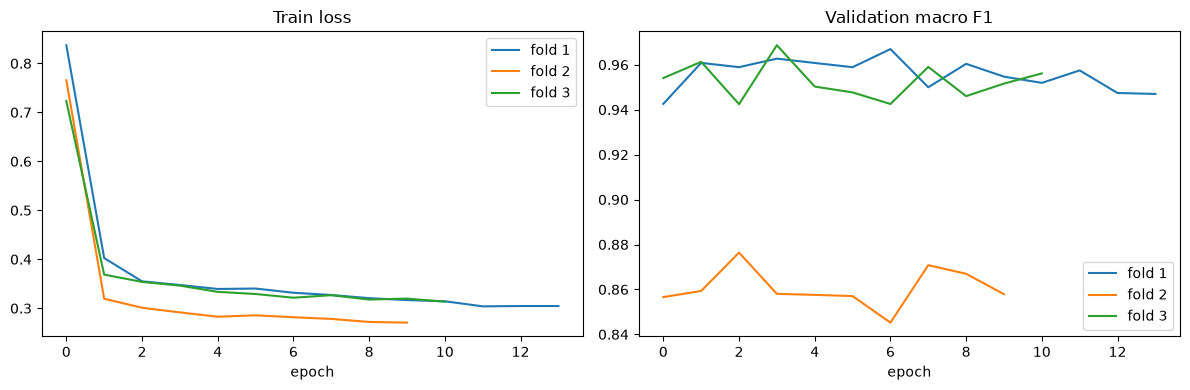

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fold, history in enumerate(cv_histories, 1):
    axes[0].plot(history["train_loss"], label=f"fold {fold}")
    axes[1].plot(history["val_f1"], label=f"fold {fold}")
axes[0].set_title("Train loss")
axes[1].set_title("Validation macro F1")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "figures/02_pairwise_learning_curves.png", dpi=150)
plt.show()


Pairwise-модель сходится еще быстрее: лучшие эпохи -- `7`, `3`, `4`. На втором fold validation F1 заметно ниже, но та же просадка была у standard EdgeMTSC и Transformer, поэтому проблема снова скорее в конкретной группе людей.


### Финальное обучение и test


In [8]:
final_epochs = int(np.median(cv_df["best_epoch"]))
X_fit, X_holdout, mean, std = standardize(X_train, X_test)
train_loader = make_loader(X_fit, y_train, shuffle=True)
test_loader = make_loader(X_holdout, y_test)

set_seed(SEED)
model = PairwiseEdgeMTSC().to(device)
final_history, _, final_train_time = fit(model, train_loader, epochs=final_epochs)
test = evaluate(model, test_loader)
latency = latency_ms(model, X_holdout)

print("final epochs:", final_epochs)
print({k: round(v, 4) for k, v in test.items() if not k.startswith("y_")})
print("params:", f"{count_parameters(model):,}")
print("train time, s:", round(final_train_time, 2))
print("latency, ms/sample:", round(latency, 4))


final epochs: 4
{'loss': 0.2492, 'accuracy': 0.9338, 'balanced_accuracy': 0.935, 'macro_f1': 0.9345}
params: 181,376
train time, s: 6.44
latency, ms/sample: 0.031


На test получаю `0.9338` accuracy и `0.9345` macro F1 -- это лучший результат из трех основных моделей. От standard EdgeMTSC выигрыш по macro F1 около `+0.0051`, то есть примерно `+0.5` п.п. Улучшение небольшое, но направление совпадает и с CV mean.


### Анализ ошибок


In [9]:
report = pd.DataFrame(classification_report(
    test["y_true"], test["y_pred"], target_names=CLASS_NAMES, output_dict=True
)).T
report


,precision,recall,f1-score,support
WALKING,0.995927,0.985887,0.990881,496.000000
WALKING_UPSTAIRS,0.988938,0.949045,0.968581,471.000000
WALKING_DOWNSTAIRS,0.931111,0.997619,0.963218,420.000000
SITTING,0.866370,0.792261,0.827660,491.000000
STANDING,0.829225,0.885338,0.856364,532.000000
LAYING,1.000000,1.000000,1.000000,537.000000
accuracy,0.933831,0.933831,0.933831,0.933831
macro avg,0.935262,0.935025,0.934451,2947.000000
weighted avg,0.934636,0.933831,0.933558,2947.000000


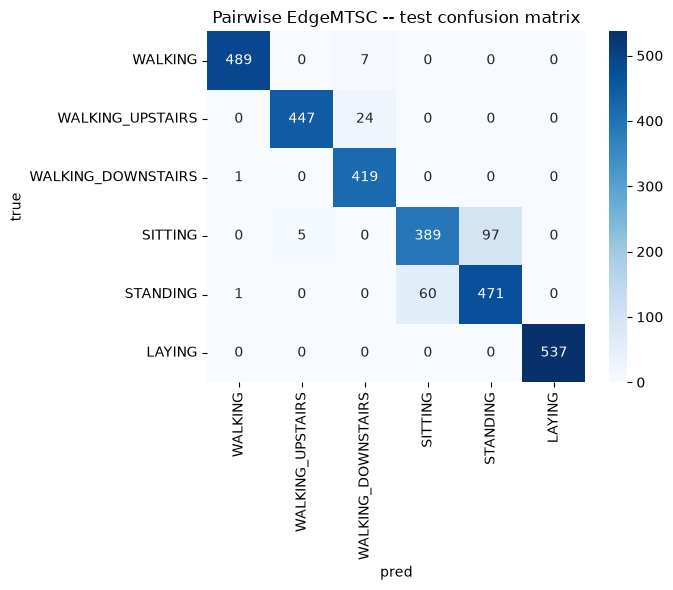

In [10]:
cm = confusion_matrix(test["y_true"], test["y_pred"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("pred")
plt.ylabel("true")
plt.title("Pairwise EdgeMTSC -- test confusion matrix")
plt.tight_layout()
plt.savefig(ROOT / "figures/02_pairwise_confusion.png", dpi=150)
plt.show()


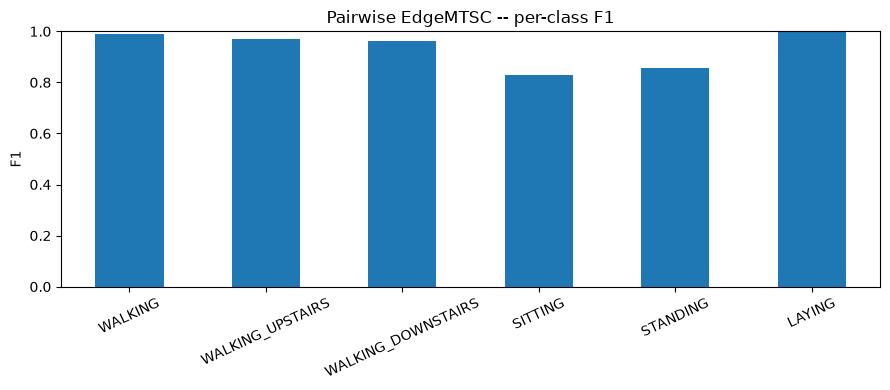

In [11]:
report.loc[CLASS_NAMES, "f1-score"].plot(kind="bar", figsize=(9, 4))
plt.ylim(0, 1)
plt.ylabel("F1")
plt.title("Pairwise EdgeMTSC -- per-class F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ROOT / "figures/02_pairwise_class_f1.png", dpi=150)
plt.show()


По ошибкам картина почти та же: `LAYING` классифицируется идеально, `WALKING*` держатся около `0.96-0.99` F1, а слабое место -- `SITTING` (`~0.83`) и `STANDING` (`~0.86`). Pairwise-механизм улучшил общий score, но полностью проблему похожих статических активностей не снял.


### Что получилось у pairwise matrices

Вес `mix.weight[i, j]` -- отдельный temporal kernel для пары `source=j -> target=i`. Он задает banded Toeplitz matrix `128 x 128`. Сначала смотрю норму kernels по всем парам, затем разворачиваю самый сильный kernel в настоящую матрицу и рисую ее.


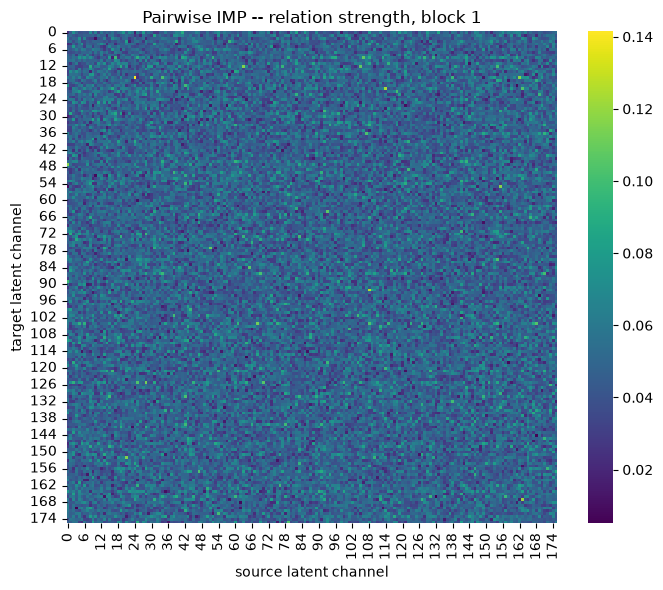

In [12]:
kernels = model.imp1.mix.weight.detach().cpu().numpy()
strength = np.linalg.norm(kernels, axis=2)

plt.figure(figsize=(7, 6))
sns.heatmap(strength, cmap="viridis")
plt.title("Pairwise IMP -- relation strength, block 1")
plt.xlabel("source latent channel")
plt.ylabel("target latent channel")
plt.tight_layout()
plt.savefig(ROOT / "figures/02_pairwise_strength.png", dpi=150)
plt.show()


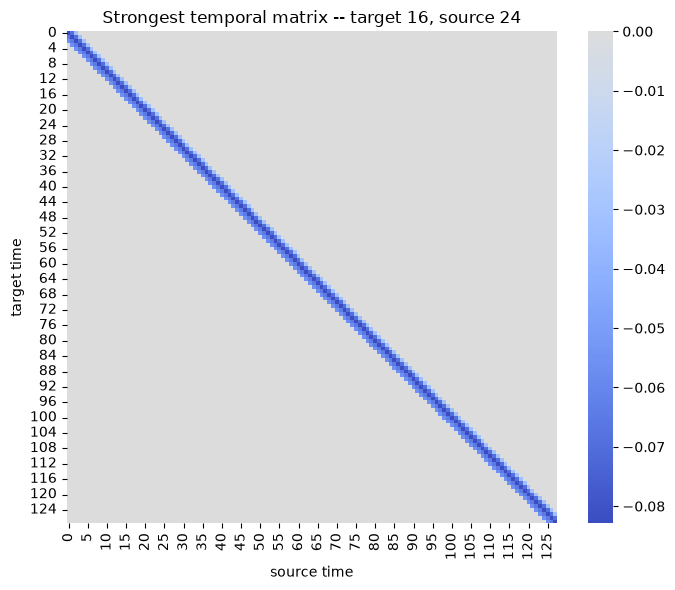

In [13]:
i, j = np.unravel_index(np.argmax(strength), strength.shape)
kernel = kernels[i, j]
T = X_train.shape[-1]
M = np.zeros((T, T))
center = len(kernel) // 2

for t in range(T):
    for k, weight in enumerate(kernel):
        s = t + k - center
        if 0 <= s < T:
            M[t, s] = weight

plt.figure(figsize=(7, 6))
sns.heatmap(M, center=0, cmap="coolwarm")
plt.title(f"Strongest temporal matrix -- target {i}, source {j}")
plt.xlabel("source time")
plt.ylabel("target time")
plt.tight_layout()
plt.savefig(ROOT / "figures/02_pairwise_temporal_matrix.png", dpi=150)
plt.show()


У самой сильной pairwise matrix основная масса веса лежит около главной диагонали. То есть модель в первую очередь смешивает близкие моменты времени, а не учит большой дальний сдвиг между каналами. Поэтому результат скорее поддерживает идею локальных lag-aware связей, чем необходимость произвольной полной `128 x 128` матрицы.

При этом из-за fixed parameter budget backbone здесь уже, чем у standard EdgeMTSC, так что `+0.5` п.п. нельзя приписать только temporal kernels как чистый causal effect. Корректная формулировка -- эта parameter-matched pairwise-конфигурация на UCI HAR оказалась немного лучше.


### Сохраняю результаты


In [14]:
result = {
    "model": "EdgeMTSC-pairwise",
    "params": count_parameters(model),
    "cv_macro_f1_mean": cv_df["macro_f1"].mean(),
    "cv_macro_f1_std": cv_df["macro_f1"].std(),
    "cv_accuracy_mean": cv_df["accuracy"].mean(),
    "final_epochs": final_epochs,
    "test_accuracy": test["accuracy"],
    "test_balanced_accuracy": test["balanced_accuracy"],
    "test_macro_f1": test["macro_f1"],
    "train_time_s": final_train_time,
    "cv_time_s": cv_df["time_s"].sum(),
    "latency_ms": latency,
}

with open(ROOT / "results/02_edgemtsc_pairwise.json", "w") as f:
    json.dump(result, f, indent=2)

cv_df.to_csv(ROOT / "results/02_edgemtsc_pairwise_cv.csv", index=False)
result


{'model': 'EdgeMTSC-pairwise',
 'params': 181376,
 'cv_macro_f1_mean': np.float64(0.9373539064675495),
 'cv_macro_f1_std': np.float64(0.05280300056148575),
 'cv_accuracy_mean': np.float64(0.9350899348151174),
 'final_epochs': 4,
 'test_accuracy': 0.9338310145911096,
 'test_balanced_accuracy': 0.9350249614515871,
 'test_macro_f1': 0.9344506292770789,
 'train_time_s': 6.438470709006651,
 'cv_time_s': np.float64(42.30099775000417),
 'latency_ms': 0.030951848983704622}